# ✍️ Handwritten Character Recognition
**CodeAlpha Machine Learning Internship — Task 3**

---

### Objective
Identify handwritten digits and characters using Convolutional Neural Networks (CNN).

### Datasets
- **Part 1:** MNIST — handwritten digits (0–9)
- **Part 2:** EMNIST Letters — handwritten alphabets (A–Z)

### Workflow
1. Install & import libraries
2. Load and explore datasets
3. Preprocess data
4. Build CNN model
5. Train and evaluate
6. Visualize results
7. Predict on custom images
8. Save model

## Step 1: Install & Import Libraries

In [1]:
!pip install tensorflow numpy pandas matplotlib seaborn opencv-python -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices("GPU")) > 0)
print('Libraries imported successfully!')

TensorFlow version: 2.20.0
GPU available: True
Libraries imported successfully!


---
# 🔢 Part 1: MNIST — Handwritten Digit Recognition (0–9)

## Step 2: Load & Explore MNIST Dataset

In [3]:
# Load MNIST — built into Keras, no download needed
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

print('MNIST Dataset:')
print(f'Training samples : {X_train_raw.shape[0]}')
print(f'Testing samples  : {X_test_raw.shape[0]}')
print(f'Image shape      : {X_train_raw.shape[1:]} (28x28 grayscale)')
print(f'Classes          : {np.unique(y_train_raw)} (digits 0-9)')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Dataset:
Training samples : 60000
Testing samples  : 10000
Image shape      : (28, 28) (28x28 grayscale)
Classes          : [0 1 2 3 4 5 6 7 8 9] (digits 0-9)


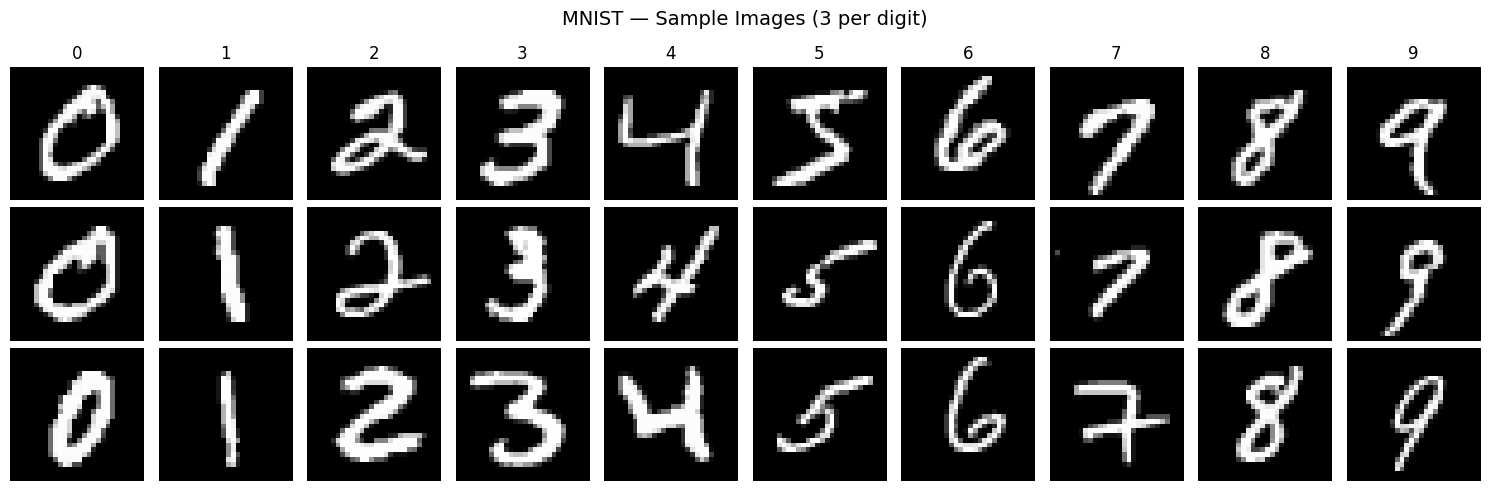

In [4]:
# Visualize sample images
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for digit in range(10):
    indices = np.where(y_train_raw == digit)[0][:3]
    for row, idx in enumerate(indices):
        axes[row, digit].imshow(X_train_raw[idx], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=12)
plt.suptitle('MNIST — Sample Images (3 per digit)', fontsize=14)
plt.tight_layout()
plt.show()

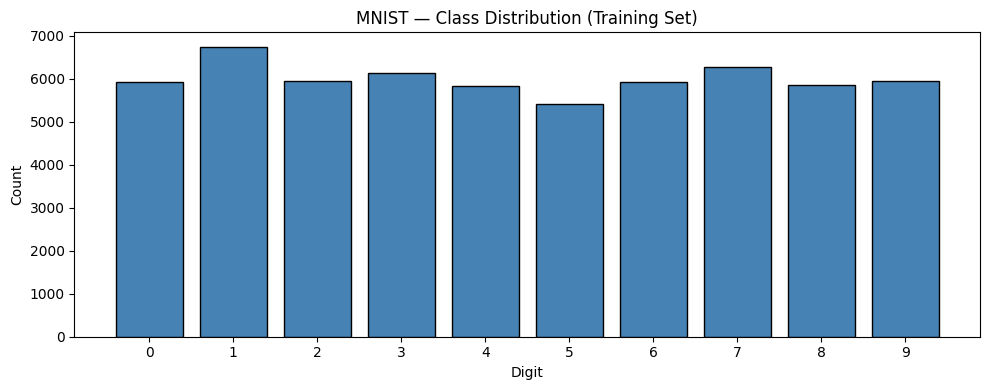

In [5]:
# Class distribution
plt.figure(figsize=(10, 4))
unique, counts = np.unique(y_train_raw, return_counts=True)
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.title('MNIST — Class Distribution (Training Set)')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

## Step 3: Preprocess Data

In [6]:
# Normalize pixel values to [0, 1]
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32') / 255.0

# Reshape to (samples, 28, 28, 1) for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train_raw, 10)
y_test  = to_categorical(y_test_raw, 10)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print('Preprocessing complete!')

X_train shape: (60000, 28, 28, 1)
X_test shape : (10000, 28, 28, 1)
y_train shape: (60000, 10)
Preprocessing complete!


In [7]:
# Data augmentation to improve generalization
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)
print('Data augmentation configured!')

Data augmentation configured!


## Step 4: Build CNN Model

In [8]:
def build_cnn(num_classes, input_shape=(28, 28, 1)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fully connected
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

mnist_model = build_cnn(num_classes=10)
mnist_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
mnist_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,506 (1.67 MB)

 Trainable params: 437,546 (1.67 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 5: Train the Model

In [9]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history_mnist = mnist_model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.8862 - loss: 0.3691 - val_accuracy: 0.9831 - val_loss: 0.0532 - learning_rate: 0.0010
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9667 - loss: 0.1102 - val_accuracy: 0.9907 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9746 - loss: 0.0812 - val_accuracy: 0.9815 - val_loss: 0.0537 - learning_rate: 0.0010
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9781 - loss: 0.0706 - val_accuracy: 0.9928 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9818 - loss: 0.0594 - val_accuracy: 0.9943 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9828 - loss: 0.0577 - val_accuracy: 0.9936 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9838 - l

## Step 6: Evaluate & Visualize

In [10]:
test_loss, test_acc = mnist_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc * 100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

Test Accuracy : 99.72%
Test Loss     : 0.0082


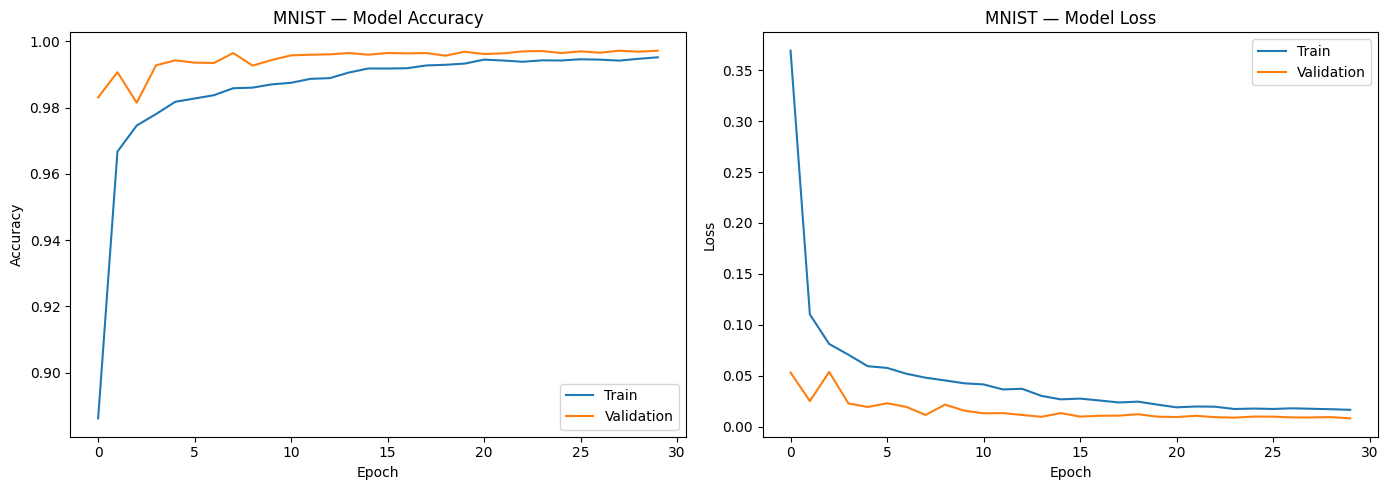

In [11]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mnist.history['accuracy'], label='Train')
axes[0].plot(history_mnist.history['val_accuracy'], label='Validation')
axes[0].set_title('MNIST — Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_mnist.history['loss'], label='Train')
axes[1].plot(history_mnist.history['val_loss'], label='Validation')
axes[1].set_title('MNIST — Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

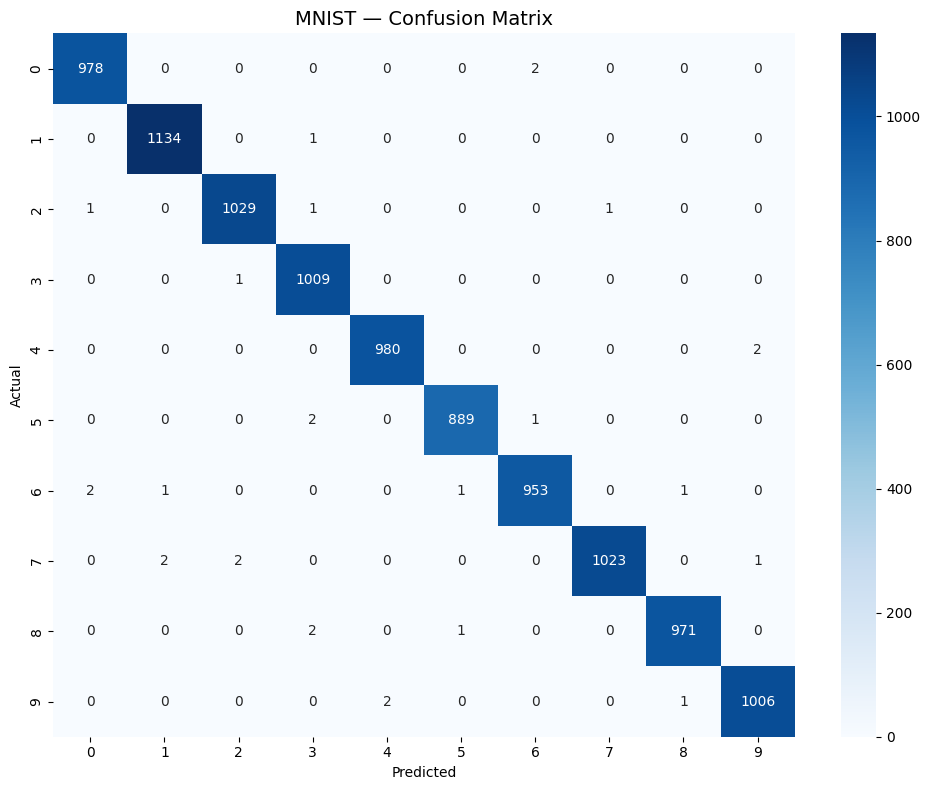

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       1.00      1.00      1.00       982
           5       1.00      1.00      1.00       892
           6       1.00      0.99      1.00       958
           7       1.00      1.00      1.00      1028
           8       1.00      1.00      1.00       974
           9       1.00      1.00      1.00      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [12]:
# Confusion matrix
y_pred = mnist_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('MNIST — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_true_classes, y_pred_classes))

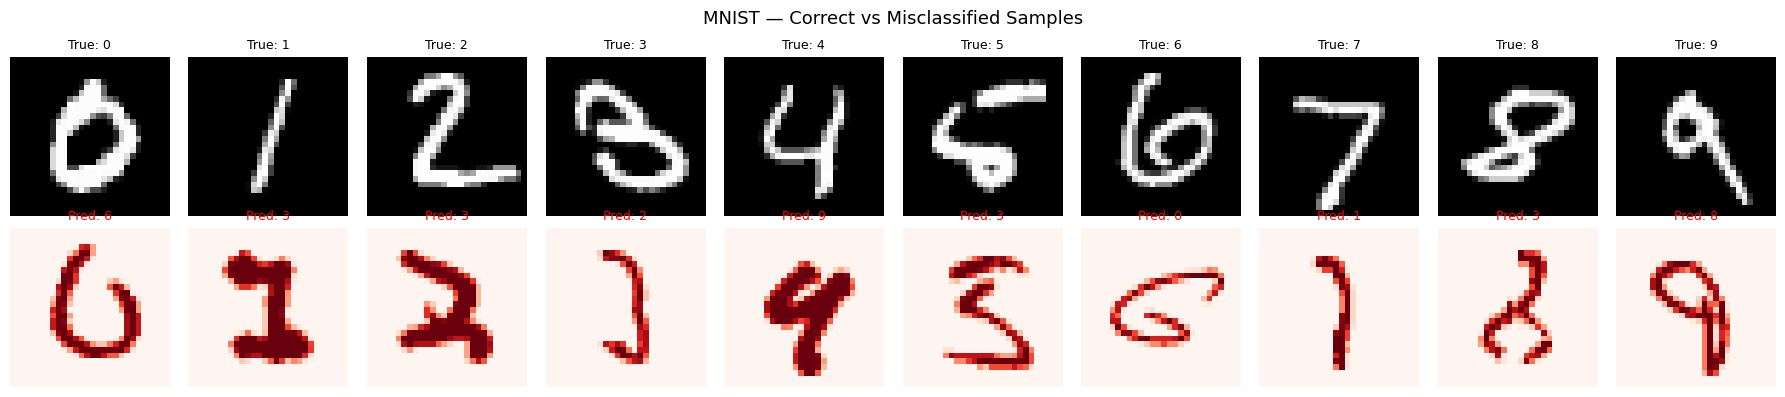

In [13]:
# Visualize predictions vs actual
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for i in range(10):
    idx = np.where(y_true_classes == i)[0][0]
    axes[0, i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'True: {i}', fontsize=9)
    axes[0, i].axis('off')

    # Find a wrong prediction for this digit
    wrong = np.where((y_true_classes == i) & (y_pred_classes != i))[0]
    if len(wrong) > 0:
        axes[1, i].imshow(X_test[wrong[0]].reshape(28, 28), cmap='Reds')
        axes[1, i].set_title(f'Pred: {y_pred_classes[wrong[0]]}', fontsize=9, color='red')
    else:
        axes[1, i].imshow(np.zeros((28, 28)), cmap='gray')
        axes[1, i].set_title('All correct!', fontsize=8, color='green')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Correct', fontsize=10)
axes[1, 0].set_ylabel('Wrong', fontsize=10)
plt.suptitle('MNIST — Correct vs Misclassified Samples', fontsize=13)
plt.tight_layout()
plt.show()

---
# 🔤 Part 2: EMNIST — Handwritten Letter Recognition (A–Z)

## Step 7: Load EMNIST Letters Dataset

In [14]:
# Install emnist package
!pip install emnist -q
from emnist import extract_training_samples, extract_test_samples

print('Downloading EMNIST Letters dataset...')
X_train_e, y_train_e = extract_training_samples('letters')
X_test_e,  y_test_e  = extract_test_samples('letters')

print(f'Training samples : {X_train_e.shape[0]}')
print(f'Testing samples  : {X_test_e.shape[0]}')
print(f'Image shape      : {X_train_e.shape[1:]}')
print(f'Classes          : {np.unique(y_train_e)} (1=A to 26=Z)')

BadZipFile: File is not a zip file

In [ ]:
# EMNIST labels are 1-indexed (1=A, 26=Z), convert to 0-indexed
y_train_e = y_train_e - 1
y_test_e  = y_test_e - 1

# Label map A-Z
label_map = {i: chr(65 + i) for i in range(26)}
print('Label mapping:', label_map)

In [ ]:
# Visualize sample letters
fig, axes = plt.subplots(2, 13, figsize=(18, 4))
for i in range(26):
    row, col = divmod(i, 13)
    idx = np.where(y_train_e == i)[0][0]
    # EMNIST images need to be rotated/flipped
    img = np.rot90(np.fliplr(X_train_e[idx]))
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(label_map[i], fontsize=10)
    axes[row, col].axis('off')
plt.suptitle('EMNIST Letters — Sample Images (A–Z)', fontsize=13)
plt.tight_layout()
plt.show()

## Step 8: Preprocess EMNIST Data

In [ ]:
# Normalize and reshape
X_train_em = X_train_e.astype('float32') / 255.0
X_test_em  = X_test_e.astype('float32') / 255.0

# Fix EMNIST orientation
X_train_em = np.array([np.rot90(np.fliplr(img)) for img in X_train_em])
X_test_em  = np.array([np.rot90(np.fliplr(img)) for img in X_test_em])

X_train_em = X_train_em.reshape(-1, 28, 28, 1)
X_test_em  = X_test_em.reshape(-1, 28, 28, 1)

y_train_em = to_categorical(y_train_e, 26)
y_test_em  = to_categorical(y_test_e, 26)

print(f'X_train shape: {X_train_em.shape}')
print(f'X_test shape : {X_test_em.shape}')
print('Preprocessing complete!')

## Step 9: Build & Train CNN for EMNIST

In [ ]:
emnist_model = build_cnn(num_classes=26)
emnist_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

datagen_em = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen_em.fit(X_train_em)

history_emnist = emnist_model.fit(
    datagen_em.flow(X_train_em, y_train_em, batch_size=128),
    epochs=30,
    validation_data=(X_test_em, y_test_em),
    callbacks=callbacks,
    verbose=1
)

In [ ]:
test_loss_em, test_acc_em = emnist_model.evaluate(X_test_em, y_test_em, verbose=0)
print(f'EMNIST Test Accuracy : {test_acc_em * 100:.2f}%')
print(f'EMNIST Test Loss     : {test_loss_em:.4f}')

In [ ]:
# Confusion matrix for EMNIST
y_pred_em = emnist_model.predict(X_test_em, verbose=0)
y_pred_em_classes = np.argmax(y_pred_em, axis=1)
y_true_em_classes = np.argmax(y_test_em, axis=1)

cm_em = confusion_matrix(y_true_em_classes, y_pred_em_classes)
plt.figure(figsize=(16, 13))
sns.heatmap(cm_em, annot=False, cmap='Blues',
            xticklabels=list(label_map.values()),
            yticklabels=list(label_map.values()))
plt.title('EMNIST Letters — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_true_em_classes, y_pred_em_classes,
                             target_names=list(label_map.values())))

---
## Step 10: Predict on Custom Handwritten Image

In [ ]:
def preprocess_custom_image(image_path):
    """Load and preprocess a custom handwritten image for prediction."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28, 28))
    img = cv2.bitwise_not(img)   # Invert: white background to black
    img = img.astype('float32') / 255.0
    img = img.reshape(1, 28, 28, 1)
    return img

def predict_digit(image_path):
    """Predict a handwritten digit from an image file."""
    img = preprocess_custom_image(image_path)
    pred = mnist_model.predict(img, verbose=0)
    digit = np.argmax(pred)
    confidence = pred[0][digit] * 100
    print(f'Predicted Digit : {digit}')
    print(f'Confidence      : {confidence:.1f}%')
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f'Prediction: {digit} ({confidence:.1f}%)')
    plt.axis('off')
    plt.show()

def predict_letter(image_path):
    """Predict a handwritten letter from an image file."""
    img = preprocess_custom_image(image_path)
    pred = emnist_model.predict(img, verbose=0)
    idx = np.argmax(pred)
    letter = label_map[idx]
    confidence = pred[0][idx] * 100
    print(f'Predicted Letter : {letter}')
    print(f'Confidence       : {confidence:.1f}%')
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f'Prediction: {letter} ({confidence:.1f}%)')
    plt.axis('off')
    plt.show()

print('Prediction functions ready!')
print('Usage: predict_digit("path/to/image.png")')
print('       predict_letter("path/to/image.png")')

In [ ]:
# --- Test on sample from test set ---
# Digit prediction
sample_idx = 5
sample_img = X_test[sample_idx]
pred = mnist_model.predict(sample_img.reshape(1, 28, 28, 1), verbose=0)
predicted = np.argmax(pred)
actual = y_test_raw[sample_idx]

plt.figure(figsize=(3, 3))
plt.imshow(sample_img.reshape(28, 28), cmap='gray')
plt.title(f'Actual: {actual}  |  Predicted: {predicted}', fontsize=12)
plt.axis('off')
plt.show()

print(f'Confidence: {pred[0][predicted]*100:.1f}%')

In [ ]:
# Upload your own handwritten image and predict
# Uncomment the lines below to upload a custom image

# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# predict_digit(filename)    # for digits
# predict_letter(filename)   # for letters

---
## Step 11: Model Comparison Summary

In [ ]:
mnist_acc  = mnist_model.evaluate(X_test, y_test, verbose=0)[1] * 100
emnist_acc = emnist_model.evaluate(X_test_em, y_test_em, verbose=0)[1] * 100

summary_df = pd.DataFrame({
    'Dataset':        ['MNIST (Digits 0-9)', 'EMNIST (Letters A-Z)'],
    'Classes':        [10, 26],
    'Train Samples':  [60000, len(X_train_em)],
    'Test Samples':   [10000, len(X_test_em)],
    'Test Accuracy':  [f'{mnist_acc:.2f}%', f'{emnist_acc:.2f}%']
})

print('Final Results Summary:')
print(summary_df.to_string(index=False))

# Bar chart comparison
plt.figure(figsize=(7, 4))
plt.bar(['MNIST (Digits)', 'EMNIST (Letters)'], [mnist_acc, emnist_acc],
        color=['steelblue', 'darkorange'], edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate([mnist_acc, emnist_acc]):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Step 12: Save Models

In [ ]:
# Save both models
mnist_model.save('mnist_digit_model.h5')
emnist_model.save('emnist_letter_model.h5')
print('Models saved!')

# Download to local machine
from google.colab import files
files.download('mnist_digit_model.h5')
files.download('emnist_letter_model.h5')
print('Models downloaded!')

---
## ✅ Summary

| Item | Detail |
|------|--------|
| Task | Handwritten Character Recognition |
| Part 1 | MNIST — Digits 0–9 (60,000 training samples) |
| Part 2 | EMNIST Letters — A–Z (uppercase) |
| Model | CNN (3 Conv blocks + Fully Connected layers) |
| Techniques | BatchNormalization, Dropout, Data Augmentation |
| Evaluation | Accuracy, Confusion Matrix, Classification Report |
| Output | Saved `.h5` model files |

**Author:** Geethanjali  
**Internship:** CodeAlpha Machine Learning Internship